<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/CustomerChurnPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data=pd.read_csv('/content/drive/MyDrive/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## **Understanding the dataset**

In [7]:
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.shape

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.describe()

In [ ]:
data.isnull().sum()

In [ ]:
print(type("TotalChargers"))

In [ ]:
data.duplicated().sum()

In [5]:
data['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [6]:
data['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


In [ ]:
print(data['gender'].value_counts())
print(data['SeniorCitizen'].value_counts())
print(data['Partner'].value_counts())
print(data['Dependents'].value_counts())
print(data['PhoneService'].value_counts())
print(data['MultipleLines'].value_counts())
print(data['InternetService'].value_counts())
print(data['OnlineSecurity'].value_counts())
print(data['OnlineBackup'].value_counts())
print(data['DeviceProtection'].value_counts())
print(data['TechSupport'].value_counts())
print(data['StreamingTV'].value_counts())
print(data['StreamingMovies'].value_counts())
print(data['Contract'].value_counts())
print(data['PaperlessBilling'].value_counts())
print(data['PaymentMethod'].value_counts())

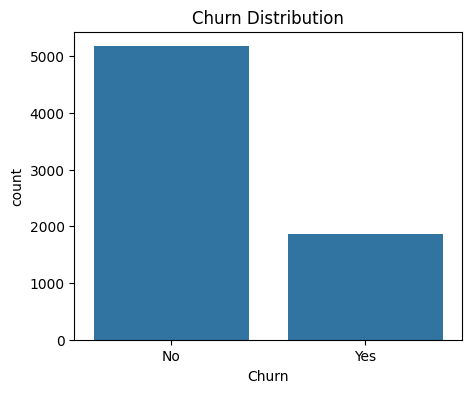

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x=data['Churn'])
plt.title("Churn Distribution")
plt.show()

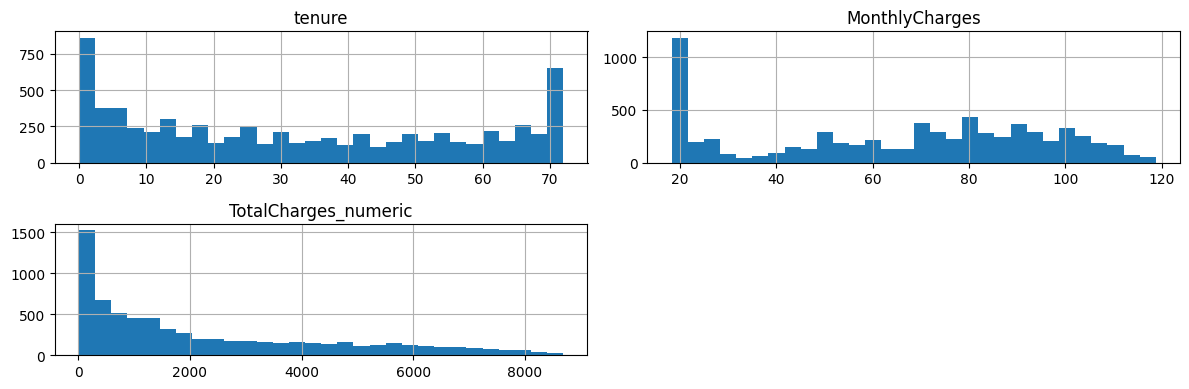

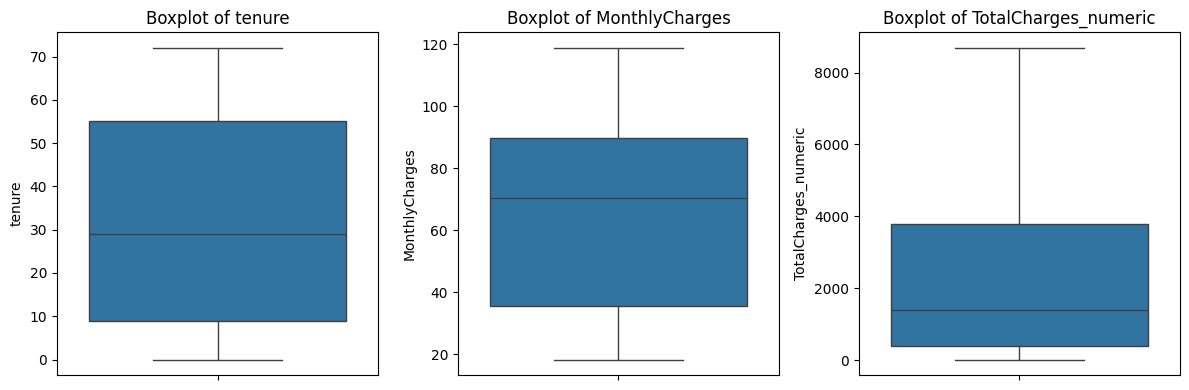

In [17]:
# Temporary conversion for plotting
data['TotalCharges_numeric'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# List of numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges_numeric']

# Histograms
data[num_cols].hist(figsize=(12,4), bins=30)
plt.tight_layout()
plt.show()

# Boxplots
plt.figure(figsize=(12,4))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

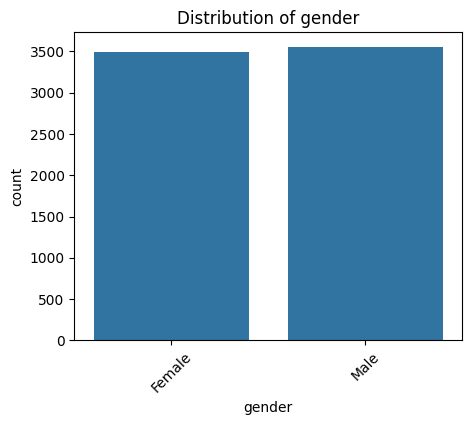

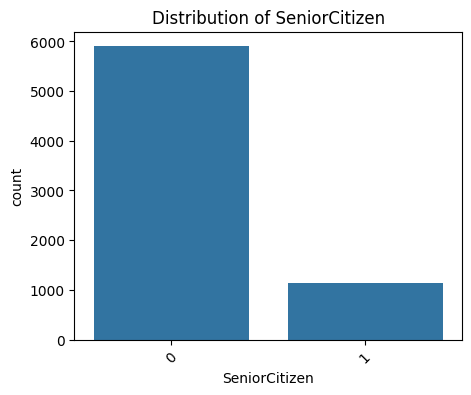

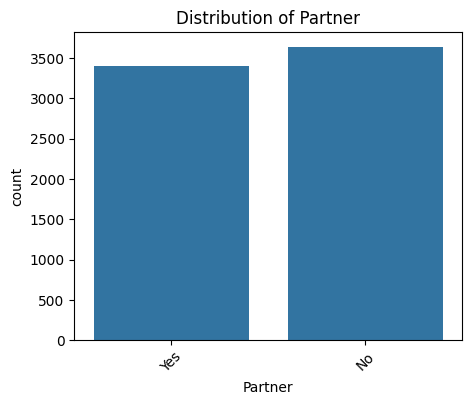

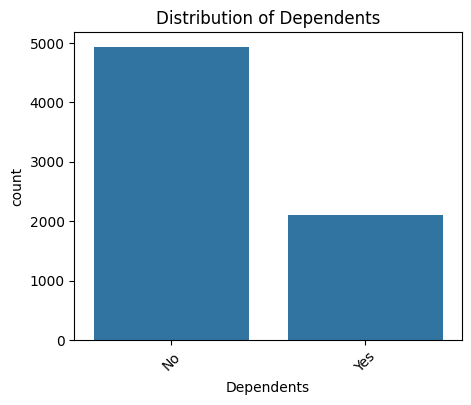

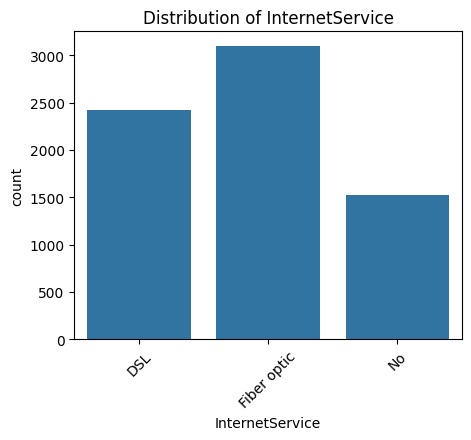

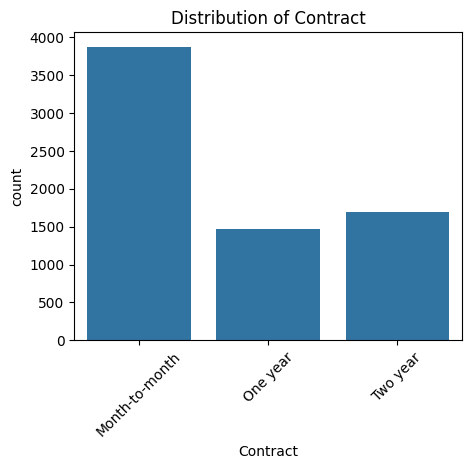

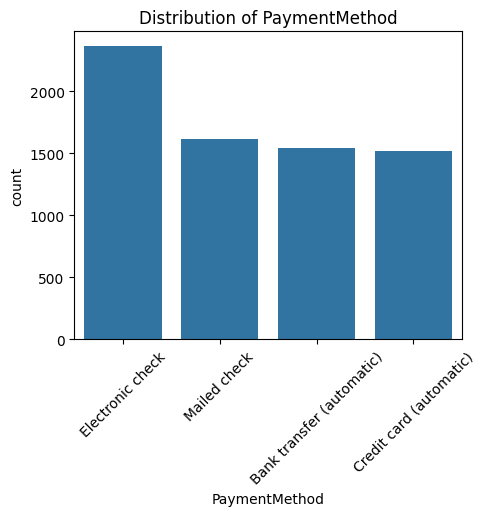

In [14]:
cat_cols = ['gender','SeniorCitizen','Partner','Dependents','InternetService','Contract','PaymentMethod']

for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=data[col])
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

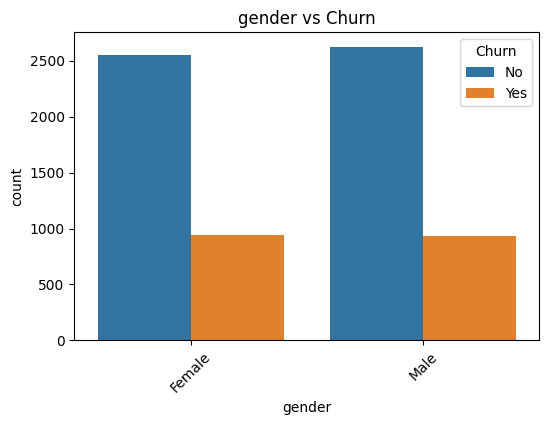

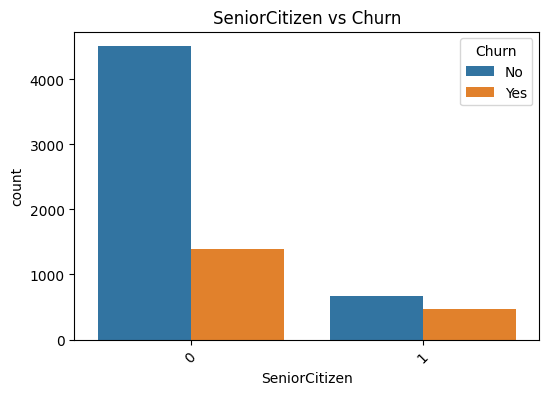

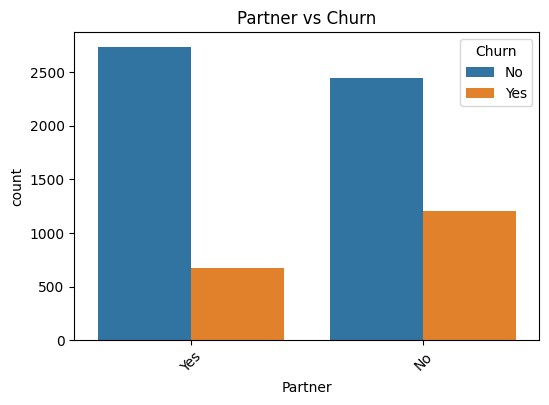

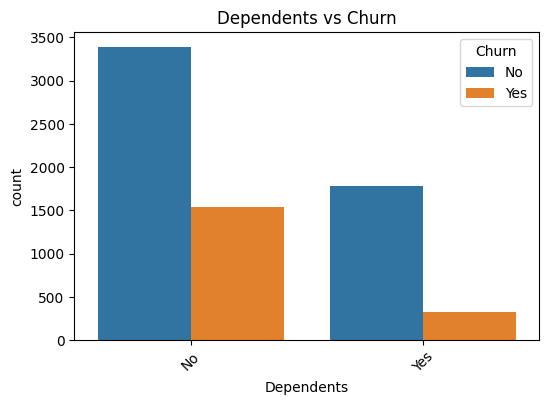

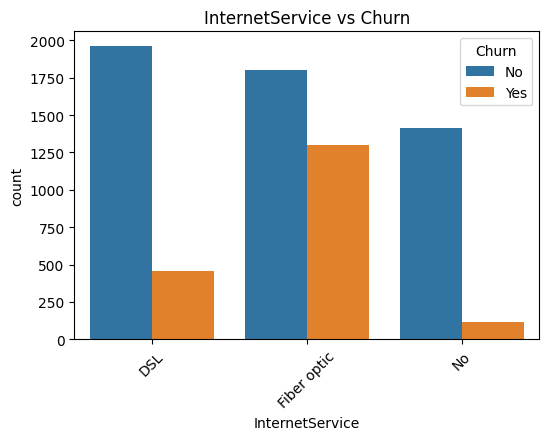

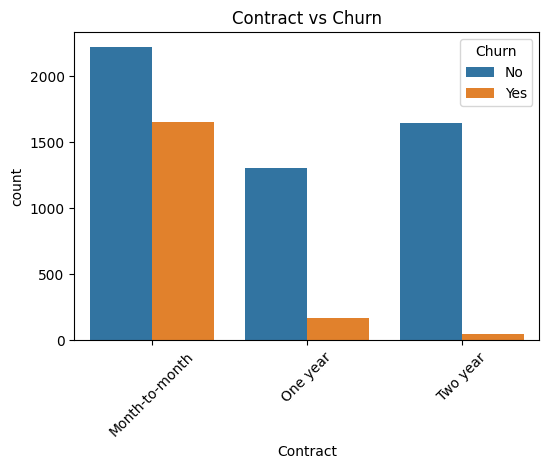

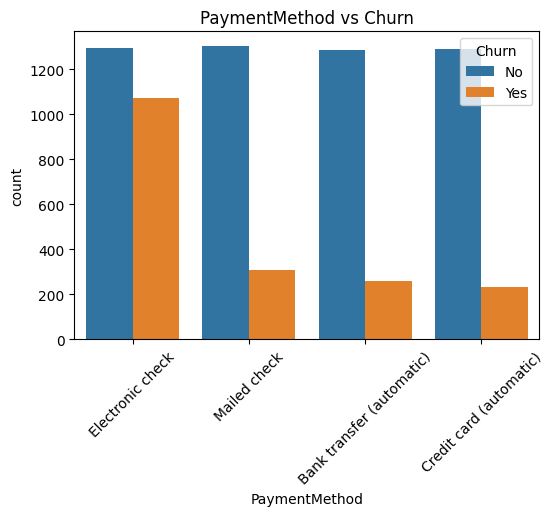

In [15]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=data, x=col, hue='Churn')
    plt.title(f"{col} vs Churn")
    plt.xticks(rotation=45)
    plt.show()

In [16]:
plt.figure(figsize=(5,4))
sns.heatmap(data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

ValueError: could not convert string to float: ' '

<Figure size 500x400 with 0 Axes>